In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
path = "data/house_prices_practice.csv"

In [24]:
df = pd.read_csv(path)

df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [25]:
df.shape

(300, 10)

### Data clearning

In [26]:
df = df.drop(["Id"], axis=1)
df = df.drop_duplicates()
df = df.dropna()
df.shape

(300, 9)

### EDA

In [27]:
df.describe()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [41]:
df.groupby("OverallQual").agg(
    avg_SalePrice = ("SalePrice", "mean", ),
    avg_TotalBsmtSF = ("TotalBsmtSF", "mean"),
    avg_GrLivArea = ("GrLivArea", "mean"),
    avg_LotArea = ("LotArea", "mean")
)

,avg_SalePrice,avg_TotalBsmtSF,avg_GrLivArea,avg_LotArea
OverallQual,,,,
1,217836.342105,1530.947368,2567.552632,9141.263158
2,221203.125000,1730.625000,2335.750000,9921.291667
3,224128.444444,1319.361111,2305.083333,9033.861111
4,241780.806452,1483.258065,2282.806452,8397.838710
5,240817.653846,1244.500000,2322.961538,9190.769231
6,253421.230769,1303.000000,2428.692308,8979.615385
7,276980.878788,1495.575758,2384.969697,8069.060606
8,277104.636364,1395.939394,2246.818182,9112.606061
9,294908.580645,1705.032258,2199.774194,8876.612903


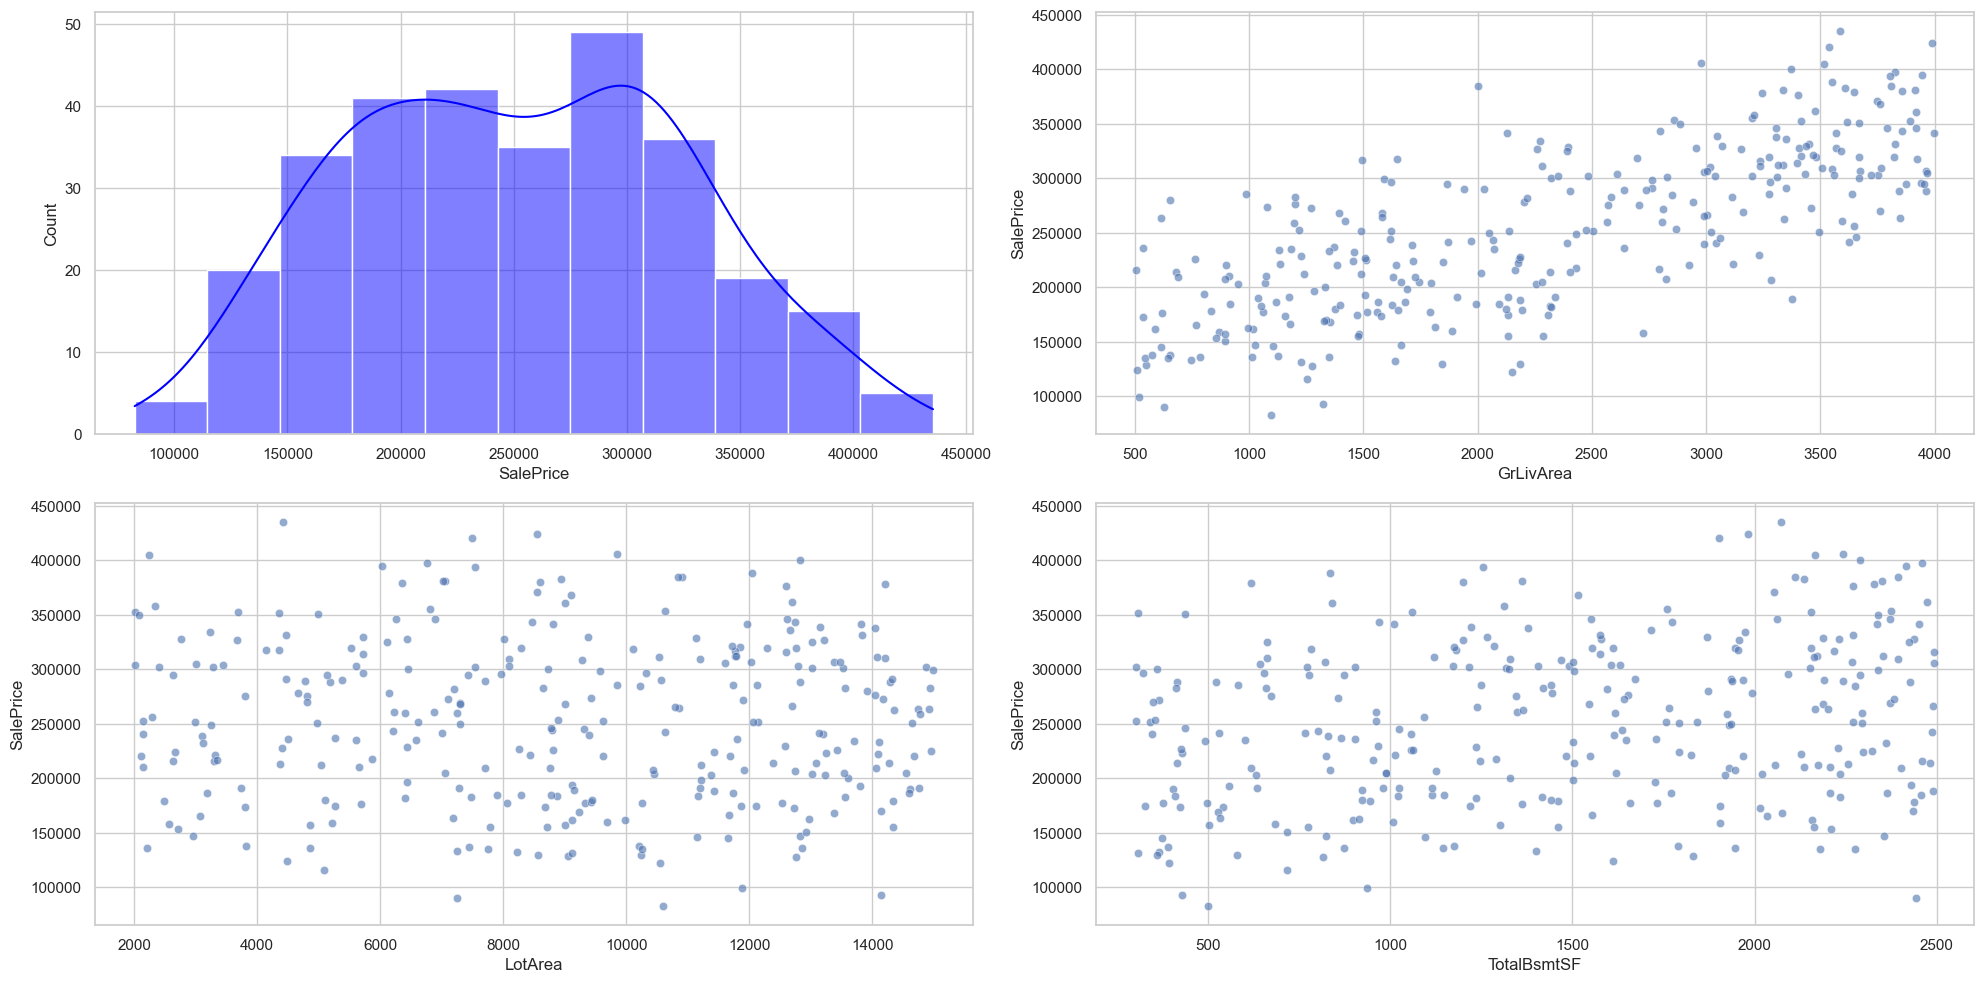

In [35]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0,0], color='blue')

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axes[0,1], alpha=0.6)

sns.scatterplot(data=df, x='LotArea', y='SalePrice', ax=axes[1,0], alpha=0.6)

sns.scatterplot(data=df, x='TotalBsmtSF', y='SalePrice', ax=axes[1,1], alpha=0.6)

plt.tight_layout()
plt.show()

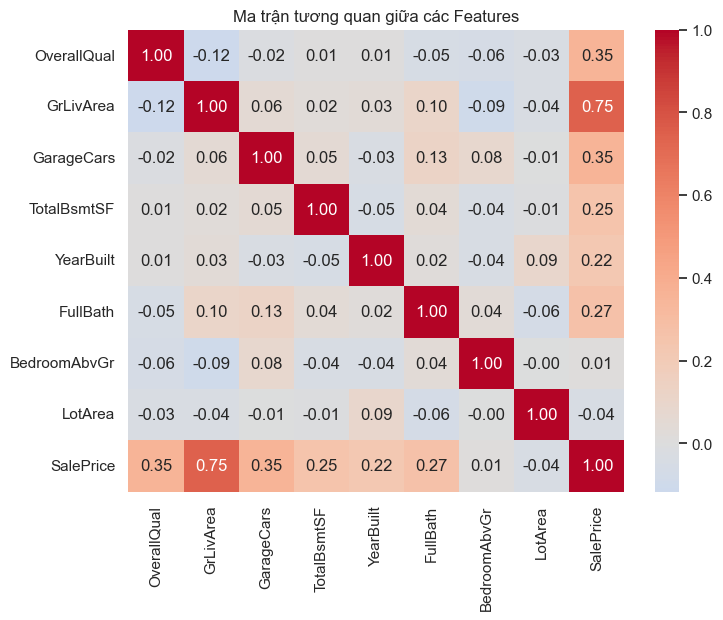

In [39]:
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các Features")
plt.show()

### Feature Engineering

In [42]:
df.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,7,1560,0,1658,1969,2,1,8059,177106
1,4,2827,2,1319,2012,3,4,13530,301044
2,8,3920,0,841,2010,1,4,9010,360609
3,5,3044,0,1058,1998,0,4,13207,240556
4,7,801,1,2428,2020,0,1,9117,193656


In [ ]:
cur_year = 2026
df["AgeHouse"] = cur_year - df["YearBuilt"]

# min-max scaler thủ công vì điểm đánh giá từ 1 - 10 -> [0.1, 1]
df["OverallQual"] = df["OverallQual"] / 10

# S_hầm + S_mặt_đất
df["TotalSF"] = df["TotalBsmtSF"] + df["GrLivArea"]

# Diện tích trung bình trên mỗi phòng -> nêu lên nếu ngang số lượng mà S_rộng hơn thì ok hơn
df["AvgRoomSize"] = df["GrLivArea"] / (df["BedroomAbvGr"] + df["FullBath"] + 1)

### Data Processing

In [ ]:
col_features = ["OverallQual", "AvgRoomSize", "AgeHouse", "TotalSF", "GarageCars", "LotArea"]

In [ ]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        
    def fit(self, X):
        X_array = np.asarray(X)
        # Tính trung bình và độ lệch chuẩn theo từng cột
        self.mean_ = np.mean(X_array, axis=0)
        self.std_ = np.std(X_array, axis=0)
        # Tránh lỗi khi chia cho 0
        self.std_[self.std_==0] = 1e-9
        return self
        
    def transform(self, X):
        X_array = np.asarray(X)
        # Áp dụng công thức: (X - mean) / std
        return (X_array - self.mean_) / self.std_
         
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [ ]:
col_scaler = ["AgeHouse", "TotalSF", "LotArea", "AvgRoomSize"]

### Model Neural Network

In [ ]:
# Config